<a href="https://colab.research.google.com/github/aymenichqa/IMDB_Sentiments_LLM/blob/main/tp2_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Prompt Engineering & Analyse de Sentiments
## Classification de critiques de films IMDB avec un LLM
**Module IA Distribuée & Systèmes Multi-Agents — EMSI**

Aymen Ichqarrane G6

In [ ]:
# Installation des dépendances
import sys, subprocess
packages = ["datasets", "scikit-learn", "pandas", "langchain-groq",
            "langchain-ollama", "python-dotenv"]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)
print("✅ Installation terminée")

✅ Installation terminée


---
## ÉTAPE 1 : Chargement et exploration du dataset

### Concept : Pourquoi IMDB ?
IMDB est un dataset de référence (benchmark) en NLP : 50 000 critiques de films étiquetées
**positive** ou **négative**. C'est parfait pour tester si un LLM comprend les sentiments.

### Concept : La bibliothèque `datasets` (HuggingFace)
Elle donne accès à des milliers de datasets préformatés. Un seul appel `load_dataset("imdb")`
télécharge, met en cache et formate le dataset automatiquement.

In [ ]:
# 1.1 — Importer les bibliothèques
from datasets import load_dataset   # HuggingFace : charger des datasets
import numpy as np                  # opérations vectorisées (np.where)
import pandas as pd                 # manipulation de tableaux de données
import json                         # manipulation du format JSON

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


In [ ]:
# 1.2 — Charger le dataset IMDB
# Le téléchargement se fait UNE SEULE FOIS (~80 Mo), puis il est mis en cache local
ds = load_dataset("imdb")

# Afficher la structure : splits disponibles, colonnes, taille
print(ds)
# → DatasetDict avec 2 clés :
#   'train' : 25 000 critiques d'entraînement
#   'test'  : 25 000 critiques de test

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
# 1.3 — Convertir le split 'train' en DataFrame pandas
# pandas = outil de manipulation de tableaux (comme Excel en Python)
train_df = ds['train'].to_pandas()

# .sample(10) : 10 lignes ALÉATOIRES (plus représentatif que .head())
train_df.sample(10)

,text,label
3368,"In the standard view, this is a purely awful m...",0
928,If you want to watch a good film about how wom...,0
6921,One of the cornerstones of low-budget cinema i...,0
288,1st watched 2/16/2002 - 4 out of 10(Dir-Arne G...,0
4260,Seriously the only good thing about this year ...,0
23794,"Though I saw this movie years ago, its impact ...",1
17038,"""My Left Foot"" is a pretty impressive film tha...",1
20284,I was surprised at how a movie could be both c...,1
13409,I love this show!<br /><br />Every time i watc...,1
19104,Methinks the best screen version of Quo Vadis?...,1


In [ ]:
# 1.4 — Vérifier l'équilibre du dataset
# 0 = critique négative, 1 = critique positive
print("Distribution des labels :")
print(train_df['label'].value_counts())

# → Un dataset ÉQUILIBRÉ a environ le même nombre d'exemples par classe
# IMDB : ~12 500 positifs + ~12 500 négatifs = équilibré ✅
# Si déséquilibré (ex: 90% positif) → le modèle prédirait toujours positif sans comprendre le texte

Distribution des labels :
label
0    12500
1    12500
Name: count, dtype: int64


In [ ]:
# 1.5 — Ajouter une colonne 'sentiment' (texte au lieu de 0/1)
# np.where(condition, valeur_si_vrai, valeur_si_faux) = if/else vectorisé ultra-rapide
# Traite toutes les 25 000 lignes en une seule opération (pas de boucle)
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

# Vérifier avec les nouvelles étiquettes textuelles
print(train_df['sentiment'].value_counts())
train_df[['text', 'label', 'sentiment']].head(3)

sentiment
negative    12500
positive    12500
Name: count, dtype: int64


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative


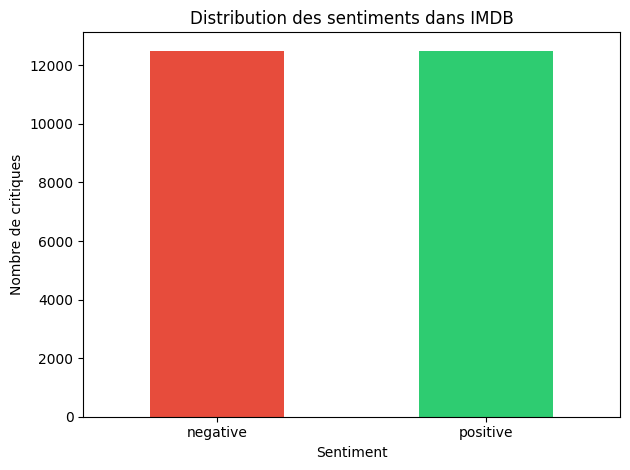

In [ ]:
# 1.6 — Visualiser la distribution (histogramme)
import matplotlib.pyplot as plt

train_df['sentiment'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Distribution des sentiments dans IMDB')
plt.xlabel('Sentiment')
plt.ylabel('Nombre de critiques')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Les deux barres doivent être à la même hauteur → dataset équilibré ✅

---
## ÉTAPE 2 : Préparation des données

### Concept : Pourquoi séparer les données ?
On divise le dataset en deux rôles distincts :
- **`examples_df` (80%)** → réservoir pour construire les exemples Few-Shot qu'on montre au LLM
- **`gold_examples_df` (20%)** → exemples de référence pour **évaluer** si le LLM prédit juste

⚠️ On ne mélange pas les deux : les exemples few-shot ne doivent pas être dans l'évaluation !

In [ ]:
# 2.1 — Séparer les données en deux parties
from sklearn.model_selection import train_test_split

# test_size=0.2   → 20% dans gold_examples (pour évaluation)
# random_state=123 → graine fixe : même résultat à chaque exécution (reproductible)
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

print(f"examples_df     (few-shot)  : {examples_df.shape}")
print(f"gold_examples_df (évaluation): {gold_examples_df.shape}")
# → (20000, 3) et (5000, 3)

examples_df     (few-shot)  : (20000, 3)
gold_examples_df (évaluation): (5000, 3)


In [ ]:
# 2.2 — Extraire 20 Gold Examples au format JSON
# Les Gold Examples = exemples dont on CONNAÎT la bonne réponse (ground truth)
# On s'en servira pour mesurer : "est-ce que le LLM a prédit la bonne étiquette ?"

columns = ['text', 'sentiment']  # On garde seulement ces 2 colonnes

gold_examples = (
    gold_examples_df[columns]
    .sample(20, random_state=123)          # 20 exemples aléatoires
    .to_json(orient='records')             # → format JSON : [{"text":"...","sentiment":"..."}, ...]
)

# orient='records' : chaque ligne DataFrame → 1 objet JSON
# C'est le format idéal pour itérer exemple par exemple
premier_exemple = json.loads(gold_examples)[0]
print("Premier gold example :")
print(f"  Sentiment : {premier_exemple['sentiment']}")
print(f"  Texte     : {premier_exemple['text'][:150]}...")

Premier gold example :
  Sentiment : negative
  Texte     : The Mummy's Tomb starts with a review of the events in The Mummy's Hand and then moves the story forward several years and across the ocean to the Uni...


In [ ]:
# 2.3 — Créer les exemples Few-Shot (équilibrés et mélangés)
# Pourquoi équilibrer ? Pour ne pas biaiser le LLM vers une seule classe
# Pourquoi mélanger ? Les LLM ont un 'biais de récence' : ils accordent plus
# d'importance aux derniers exemples. Si on met tous les positifs en dernier,
# le modèle sera biaisé vers 'positive'.

def create_examples(dataset, n=4):
    """Crée n exemples positifs + n exemples négatifs, mélangés aléatoirement."""

    # Sélectionner n critiques positives
    positive_reviews_df = (
        dataset[dataset['sentiment'] == 'positive'][columns]
        .sample(n)
    )
    # Sélectionner n critiques négatives
    negative_reviews_df = (
        dataset[dataset['sentiment'] == 'negative'][columns]
        .sample(n)
    )
    # Fusionner et mélanger (shuffle)
    examples_combined = pd.concat([positive_reviews_df, negative_reviews_df])
    examples_shuffled  = examples_combined.sample(2 * n, replace=False)  # replace=False = pas de doublons

    return examples_shuffled.to_json(orient='records')

# Créer 4 exemples few-shot : 2 positifs + 2 négatifs, mélangés
few_shot_examples = create_examples(examples_df, n=2)

print("Few-shot examples créés :")
for ex in json.loads(few_shot_examples):
    print(f"  [{ex['sentiment']:8s}] {ex['text'][:80]}...")

Few-shot examples créés :
  [positive] This little film had long been on my "keeper" list. Do people realize how stress...
  [negative] SPOILERS THROUGHOUT!!!!<br /><br />I had read the book "1st to die" and wanted t...
  [negative] The one sheets and newspaper campaign suggested (as often they did) a far more l...
  [positive] I pulled down a VHS box from my vast collection - many unseen - and picked out a...


---
## ÉTAPE 3 : Construction des prompts

C'est le **cœur du Prompt Engineering**. On va construire 3 types de prompts :

| Stratégie | Exemples ? | Raisonnement ? | Complexité |
|-----------|-----------|----------------|------------|
| **Zero-Shot** | ❌ Aucun | ❌ Non | Simple |
| **Few-Shot** | ✅ 2-8 | ❌ Non | Moyen |
| **CoT + Few-Shot** | ✅ 2-8 | ✅ Oui (étapes) | Avancé |

In [ ]:
# 3.1 — Template du message utilisateur
# {movie_review} sera remplacé par le texte de chaque critique
# Les triple backticks ``` = délimiteurs qui séparent l'instruction du contenu
# → Réduit le risque de 'prompt injection' (le LLM confond texte et instruction)

user_prompt_template = """```{movie_review}```"""

# Test rapide
exemple_review = "This movie was absolutely fantastic!"
print(user_prompt_template.format(movie_review=exemple_review))

```This movie was absolutely fantastic!```


In [ ]:
# 3.2 — Prompt Zero-Shot
# AUCUN exemple → le LLM s'appuie uniquement sur son préentraînement
# Plus simple mais parfois moins précis pour des formats très stricts

zero_shot_prompt_system = """
Classify the sentiment of the following movie review
as either "positive" or "negative":

Movie review will be delimited by triple backticks ```
in the input answer only as 'positive' or 'negative'.
Do not explain your answer.
"""

# Structure : 1 seul message système, pas d'exemples
zero_shot_prompt = [
    {"role": "system", "content": zero_shot_prompt_system}
]

print("✅ Zero-Shot prompt créé")
print(f"  Nombre de messages : {len(zero_shot_prompt)}")
print(f"  Rôles présents    : {[m['role'] for m in zero_shot_prompt]}")

✅ Zero-Shot prompt créé
  Nombre de messages : 1
  Rôles présents    : ['system']


In [ ]:
# 3.3 — Prompt Few-Shot
# On montre des exemples déjà résolus sous forme de conversation simulée :
#   user → critique à classifier
#   assistant → réponse correcte
# Le LLM apprend ainsi le format attendu 'par l'exemple'

# Message système pour le few-shot (même instruction que zero-shot)
few_shot_prompt_system = """
Classify the sentiment of the following movie review
as either "positive" or "negative":

Movie review will be delimited by triple backticks ```
in the input answer only as 'positive' or 'negative'.
Do not explain your answer.
"""

def create_prompt(system_message, examples, user_prompt_template):
    """Construit un prompt few-shot : système + paires user/assistant d'exemples."""

    # Démarrer avec le message système
    prompt = [
        {"role": "system", "content": system_message}
    ]

    # Ajouter chaque exemple comme une PAIRE user/assistant
    # → Simule une conversation passée pour que le LLM comprenne le format
    for example in json.loads(examples):
        review    = example['text']       # texte de la critique
        sentiment = example['sentiment']  # étiquette connue

        # Message user : la critique à classifier
        prompt.append({
            "role": "user",
            "content": user_prompt_template.format(movie_review=review)
        })
        # Message assistant : la bonne réponse (on la connaît déjà)
        prompt.append({
            "role": "assistant",
            "content": f"{sentiment}"
        })

    return prompt

# Construire le few-shot prompt
few_shot_prompt = create_prompt(few_shot_prompt_system, few_shot_examples, user_prompt_template)

print("✅ Few-Shot prompt créé")
print(f"  Nombre de messages : {len(few_shot_prompt)}")
print(f"  Structure          : {[m['role'] for m in few_shot_prompt]}")
# → ['system', 'user', 'assistant', 'user', 'assistant', ...]
# La vraie question sera ajoutée à la fin lors de l'appel

✅ Few-Shot prompt créé
  Nombre de messages : 9
  Structure          : ['system', 'user', 'assistant', 'user', 'assistant', 'user', 'assistant', 'user', 'assistant']


In [ ]:
# 3.4 — Prompt Chain-of-Thought (CoT)
# On demande au LLM de RÉFLÉCHIR ÉTAPE PAR ÉTAPE avant de répondre
# Même sans montrer son raisonnement, le simple fait d'y être invité améliore la qualité
# Technique particulièrement efficace pour les tâches ambiguës ou complexes

cot_few_shot_prompt_system = """
Classify the sentiment of the following movie review
as either "positive" or "negative":

Movie review will be delimited by triple backticks ```
in the input answer only as 'positive' or 'negative'.
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think
   through the options for sentiment provided
2. Consider the overall sentiment of the review and
   estimate the probability of the review being positive

To reiterate, your answer should strictly only contain
the label: positive or negative
"""

# Même fonction create_prompt, juste le message système est différent
cot_few_shot_prompt = create_prompt(
    cot_few_shot_prompt_system, few_shot_examples, user_prompt_template
)

print("✅ CoT Few-Shot prompt créé")
print(f"  Nombre de messages : {len(cot_few_shot_prompt)}")
print()
print("📊 Récapitulatif des 3 prompts :")
print(f"  Zero-Shot  : {len(zero_shot_prompt)} message(s)")
print(f"  Few-Shot   : {len(few_shot_prompt)} message(s) (système + {len(json.loads(few_shot_examples))} exemples × 2)")
print(f"  CoT        : {len(cot_few_shot_prompt)} message(s) (même structure + raisonnement dans system)")

✅ CoT Few-Shot prompt créé
  Nombre de messages : 9

📊 Récapitulatif des 3 prompts :
  Zero-Shot  : 1 message(s)
  Few-Shot   : 9 message(s) (système + 4 exemples × 2)
  CoT        : 9 message(s) (même structure + raisonnement dans system)


---
## ÉTAPE 4 : Évaluation avec le F1-Score

### Concept : F1-Score
On ne peut pas juste compter les bonnes réponses (accuracy) car ça peut être trompeur. Le **F1-Score** combine :
- **Précision** : parmi les prédictions "positive", combien étaient vraiment positive ?
- **Rappel** : parmi les vraies "positive", combien a-t-on bien détectées ?

F1 = 2 × (précision × rappel) / (précision + rappel) → entre **0.0** (nul) et **1.0** (parfait)

### Concept : Groq à la place d'OpenAI
On utilise Groq (gratuit) au lieu d'OpenAI pour éviter les problèmes de quota.

In [ ]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from google.colab import userdata # Import userdata to access Colab secrets

# Retrieve GROQ_API_KEY from Colab secrets
userdata.get('GROQ_API_KEY')
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Set the environment variable. Langchain will pick this up.
import os
os.environ['GROQ_API_KEY'] = GROQ_API_KEY

# Créer l'instance Groq
# temperature=0 → réponses déterministes (pas d'aléatoire) → résultats reproductibles
llm1 = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

# Test rapide pour vérifier que ça fonctionne
test = llm1.invoke([{"role": "user", "content": "Réponds juste 'OK'"}])
print(f"Test connexion Groq : {test.content}")
print("✅ LLM prêt")

Test connexion Groq : OK
✅ LLM prêt


In [ ]:
# 4.2 — La fonction d'évaluation
# Pour chaque gold example :
#   1. Envoyer le prompt + la critique au LLM
#   2. Lire sa prédiction (positive/negative)
#   3. Comparer avec la vraie étiquette
#   4. Calculer le F1-Score final

from sklearn.metrics import f1_score

def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm):
    """Évalue un prompt sur les gold examples. Retourne le F1-Score."""

    predicted_sentiment  = []  # ← CORRECTION : pas de virgule (sinon tuple au lieu de liste !)
    ground_truth_sentiment = []

    total = len(json.loads(gold_examples))

    for i, example in enumerate(json.loads(gold_examples)):
        review    = example['text']       # texte de la critique
        sentiment = example['sentiment']  # vraie étiquette (ground truth)

        # Construire le message utilisateur avec la critique
        user_input = [{
            "role": "user",
            "content": user_prompt_template.format(movie_review=review)
        }]

        try:
            # Appeler le LLM : prompt (système + exemples) + user_input (la question)
            # L'opérateur + concatène deux listes Python
            resp = llm.invoke(prompt + user_input)

            # Analyser la réponse du modèle
            response_text = resp.content.strip().lower()
            if 'negative' in response_text:
                predicted = 'negative'
            elif 'positive' in response_text:
                predicted = 'positive'
            else:
                predicted = 'unknown'  # réponse inattendue

            # Afficher la progression
            status = '✅' if predicted == sentiment else '❌'
            print(f"  [{i+1:2d}/{total}] {status} Prédit: {predicted:8s} | Vrai: {sentiment}")

            predicted_sentiment.append(predicted)    # ← CORRECTION du nom de variable
            ground_truth_sentiment.append(sentiment)

        except Exception as e:
            print(f"  [{i+1:2d}/{total}] ⚠️  Erreur : {e}")
            continue  # passer à l'exemple suivant

    # Calculer le F1-Score
    # average='micro' → F1 global : nb total correct / nb total prédictions
    score = f1_score(
        predicted_sentiment,
        ground_truth_sentiment,
        average='micro'
    )
    return score

print("✅ Fonction evaluate_prompt définie")

✅ Fonction evaluate_prompt définie


In [ ]:
# 4.3a — Évaluer le prompt ZERO-SHOT
# ⏱ Prend ~1-2 minutes (20 appels API)
print("=" * 50)
print("📊 Évaluation ZERO-SHOT")
print("=" * 50)

score_zero = evaluate_prompt(
    zero_shot_prompt, gold_examples, user_prompt_template, llm1
)

print(f"\n🎯 F1 Zero-Shot : {score_zero:.4f}")

📊 Évaluation ZERO-SHOT
  [ 1/20] ✅ Prédit: negative | Vrai: negative
  [ 2/20] ✅ Prédit: positive | Vrai: positive
  [ 3/20] ✅ Prédit: negative | Vrai: negative
  [ 4/20] ✅ Prédit: negative | Vrai: negative
  [ 5/20] ✅ Prédit: negative | Vrai: negative
  [ 6/20] ❌ Prédit: negative | Vrai: positive
  [ 7/20] ✅ Prédit: positive | Vrai: positive
  [ 8/20] ✅ Prédit: positive | Vrai: positive
  [ 9/20] ✅ Prédit: positive | Vrai: positive
  [10/20] ✅ Prédit: positive | Vrai: positive
  [11/20] ✅ Prédit: positive | Vrai: positive
  [12/20] ✅ Prédit: positive | Vrai: positive
  [13/20] ✅ Prédit: positive | Vrai: positive
  [14/20] ✅ Prédit: negative | Vrai: negative
  [15/20] ✅ Prédit: negative | Vrai: negative
  [16/20] ✅ Prédit: negative | Vrai: negative
  [17/20] ✅ Prédit: positive | Vrai: positive
  [18/20] ✅ Prédit: positive | Vrai: positive
  [19/20] ✅ Prédit: positive | Vrai: positive
  [20/20] ✅ Prédit: negative | Vrai: negative

🎯 F1 Zero-Shot : 0.9500


In [ ]:
# 4.3b — Évaluer le prompt FEW-SHOT
print("=" * 50)
print("📊 Évaluation FEW-SHOT")
print("=" * 50)

score_few = evaluate_prompt(
    few_shot_prompt, gold_examples, user_prompt_template, llm1
)

print(f"\n🎯 F1 Few-Shot : {score_few:.4f}")

📊 Évaluation FEW-SHOT
  [ 1/20] ✅ Prédit: negative | Vrai: negative
  [ 2/20] ✅ Prédit: positive | Vrai: positive
  [ 3/20] ✅ Prédit: negative | Vrai: negative
  [ 4/20] ✅ Prédit: negative | Vrai: negative
  [ 5/20] ✅ Prédit: negative | Vrai: negative
  [ 6/20] ✅ Prédit: positive | Vrai: positive
  [ 7/20] ✅ Prédit: positive | Vrai: positive
  [ 8/20] ✅ Prédit: positive | Vrai: positive
  [ 9/20] ✅ Prédit: positive | Vrai: positive
  [10/20] ✅ Prédit: positive | Vrai: positive
  [11/20] ✅ Prédit: positive | Vrai: positive
  [12/20] ✅ Prédit: positive | Vrai: positive
  [13/20] ✅ Prédit: positive | Vrai: positive
  [14/20] ✅ Prédit: negative | Vrai: negative
  [15/20] ✅ Prédit: negative | Vrai: negative
  [16/20] ✅ Prédit: negative | Vrai: negative
  [17/20] ✅ Prédit: positive | Vrai: positive
  [18/20] ✅ Prédit: positive | Vrai: positive
  [19/20] ✅ Prédit: positive | Vrai: positive
  [20/20] ✅ Prédit: negative | Vrai: negative

🎯 F1 Few-Shot : 1.0000


In [ ]:
# 4.3c — Évaluer le prompt COT + FEW-SHOT
print("=" * 50)
print("📊 Évaluation CoT + FEW-SHOT")
print("=" * 50)

score_cot = evaluate_prompt(
    cot_few_shot_prompt, gold_examples, user_prompt_template, llm1
)

print(f"\n🎯 F1 CoT : {score_cot:.4f}")

📊 Évaluation CoT + FEW-SHOT
  [ 1/20] ✅ Prédit: negative | Vrai: negative
  [ 2/20] ✅ Prédit: positive | Vrai: positive
  [ 3/20] ✅ Prédit: negative | Vrai: negative
  [ 4/20] ✅ Prédit: negative | Vrai: negative
  [ 5/20] ✅ Prédit: negative | Vrai: negative
  [ 6/20] ✅ Prédit: positive | Vrai: positive
  [ 7/20] ✅ Prédit: positive | Vrai: positive
  [ 8/20] ✅ Prédit: positive | Vrai: positive
  [ 9/20] ✅ Prédit: positive | Vrai: positive
  [10/20] ✅ Prédit: positive | Vrai: positive
  [11/20] ✅ Prédit: positive | Vrai: positive
  [12/20] ✅ Prédit: positive | Vrai: positive
  [13/20] ✅ Prédit: positive | Vrai: positive
  [14/20] ✅ Prédit: negative | Vrai: negative
  [15/20] ✅ Prédit: negative | Vrai: negative
  [16/20] ✅ Prédit: negative | Vrai: negative
  [17/20] ✅ Prédit: positive | Vrai: positive
  [18/20] ✅ Prédit: positive | Vrai: positive
  [19/20] ✅ Prédit: positive | Vrai: positive
  [20/20] ✅ Prédit: negative | Vrai: negative

🎯 F1 CoT : 1.0000


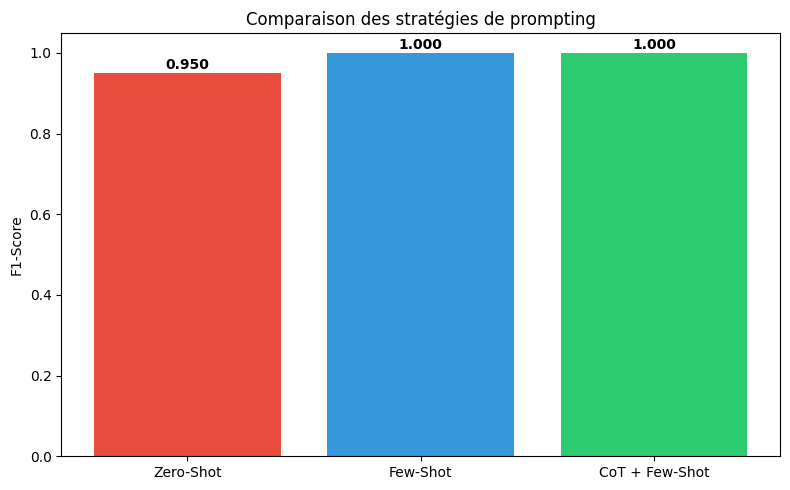


📊 RÉSULTATS FINAUX :
  Zero-Shot      : 0.9500
  Few-Shot       : 1.0000
  CoT + Few-Shot : 1.0000

🏆 Meilleure stratégie : Few-Shot (F1 = 1.0000)


In [ ]:
# Récapitulatif des 3 scores
import matplotlib.pyplot as plt

prompts  = ['Zero-Shot', 'Few-Shot', 'CoT + Few-Shot']
scores   = [score_zero, score_few, score_cot]
colors   = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(prompts, scores, color=colors)
plt.ylim(0, 1.05)
plt.ylabel('F1-Score')
plt.title('Comparaison des stratégies de prompting')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 RÉSULTATS FINAUX :")
print(f"  Zero-Shot      : {score_zero:.4f}")
print(f"  Few-Shot       : {score_few:.4f}")
print(f"  CoT + Few-Shot : {score_cot:.4f}")
best = prompts[scores.index(max(scores))]
print(f"\n🏆 Meilleure stratégie : {best} (F1 = {max(scores):.4f})")